In [1]:
from glob import glob
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
from torchvision import tv_tensors
from sklearn.model_selection import train_test_split

import torchmetrics
from torchmetrics.segmentation import DiceScore
from torchmetrics.classification import MulticlassJaccardIndex

In [2]:
# Download the dataset using wget
!wget -O images.tar.gz https://thor.robots.ox.ac.uk/pets/images.tar.gz
!wget -O annotations.tar.gz https://thor.robots.ox.ac.uk/pets/annotations.tar.gz

# Extract the archives
!tar -xf images.tar.gz
!tar -xf annotations.tar.gz

--2026-09-27 02:23:47--  https://thor.robots.ox.ac.uk/pets/images.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 791918971 (755M) [application/octet-stream]
Saving to: ‘images.tar.gz’

images.tar.gz       100%[===================>] 755.23M  19.8MB/s    in 38s     

2026-09-27 02:24:26 (20.0 MB/s) - ‘images.tar.gz’ saved [791918971/791918971]

--2026-09-27 02:24:26--  https://thor.robots.ox.ac.uk/pets/annotations.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19173078 (18M) [application/octet-stream]
Saving to: ‘annotations.tar.gz’

annotations.tar.gz  100%[===================>]  18.28M  19.2MB/s    in 1.0s    

2026-09-27 02:24:27 (19.2 MB/s)

In [3]:
SEED = 42
EPOCHS = 30
BATCH = 8
LEARNING_RATE = 2e-4

torch.cuda.manual_seed(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)

## Load data

In [4]:
class PetDataset(Dataset):
   """ Dataset for loading pet image and annotations """
   def __init__(self, image_paths, mask_paths, transforms=None):
       self.image_paths = image_paths
       self.mask_paths = mask_paths
       self.transforms = transforms

   def __len__(self):
       return len(self.image_paths)

   def __getitem__(self, idx):
       image = self.image_paths[idx]
       mask = self.mask_paths[idx]

       image = Image.open(image).convert("RGB")
       mask = Image.open(mask).convert("L")

       # convert to tv image and mask for v2 transform
       image = tv_tensors.Image(image)
       mask = tv_tensors.Mask(mask)

       if self.transforms is not None:
          image, mask = self.transforms(image, mask)

       # Convert mask to long tensor first to prevent unsigned uint8 underflow
       mask = mask.to(torch.int64)
       mask = mask - 1 # [1, 2, 3] -> [0, 1, 2]

       return image, mask

In [5]:
IMG_ROOT = "images"
ANNOTATION_ROOT = "annotations/trimaps"

image_paths = sorted(glob(f"{IMG_ROOT}/*jpg"))
annotation_paths = sorted(glob(f"{ANNOTATION_ROOT}/*png"))

img_train, img_val, mask_train, mask_val = train_test_split(image_paths, annotation_paths, test_size=0.2, random_state=SEED)


train_transform = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomResizedCrop(size=(256, 256), scale=(0.8, 1.0)),
    #v2.RandomRotation(degrees=15, fill=0),
    v2.ColorJitter(0.01),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                  std=[0.229, 0.224, 0.225]),
])

val_transform = v2.Compose([
    v2.Resize((256, 256)),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                  std=[0.229, 0.224, 0.225]),
])


train_data = PetDataset(
  image_paths=img_train,
  mask_paths=mask_train,
  transforms=train_transform
)

val_data = PetDataset(
  image_paths=img_val,
  mask_paths=mask_val,
  transforms=val_transform
)

In [6]:
def visualize(image, mask, num_classes, pred=None, show_error=False, cmap="viridis"):
    """ Show the image, mask and prediction if provided. Show error of prediction if show_error=True """
    if pred is None and show_error:
        raise ValueError("Showing error is only possible when pred is given")

    image = image.permute(1, 2, 0).cpu().numpy()  # [3,H,W] -> [H,W,3]
    
    if mask.ndim == 3:
        mask = mask.squeeze(0)
        
    mask = mask.cpu().numpy()

    vmin, vmax = 0, num_classes - 1

    n = 2 + (pred is not None) + show_error
    fig, ax = plt.subplots(1, n, figsize=(4 * n, 4))

    ax[0].imshow(image); ax[0].set_title("Image")
    ax[1].imshow(mask, cmap=cmap, vmin=vmin, vmax=vmax); ax[1].set_title("Mask")

    i = 2
    pred_np = None
    if pred is not None:
        pred_np = pred.cpu().numpy()
        ax[i].imshow(pred_np, cmap=cmap, vmin=vmin, vmax=vmax)
        ax[i].set_title("Prediction")
        i += 1

    if show_error:
        error = (mask != pred_np).astype(float)
        im = ax[i].imshow(error, cmap="Reds", vmin=0, vmax=1)
        ax[i].set_title("Error")
        fig.colorbar(im, ax=ax[i], fraction=0.046)

    for a in ax:
        a.axis("off")
    plt.tight_layout()
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.64].


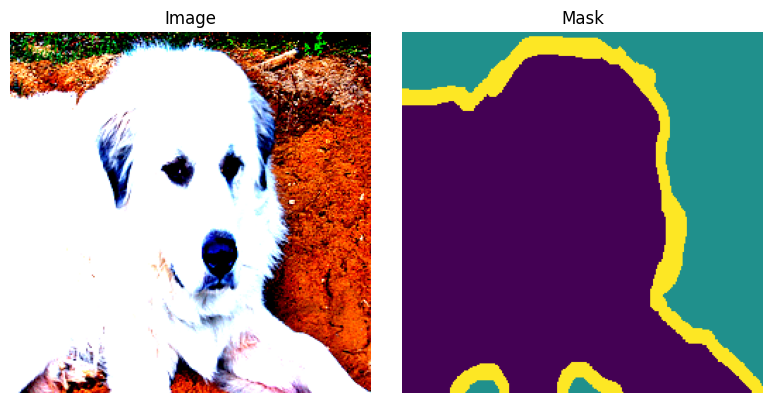

In [7]:
img, mask = val_data[-1]

visualize(img, mask, num_classes=3, cmap="viridis")

In [8]:
num_classes = len(torch.unique(mask))
torch.unique(mask)

tensor([0, 1, 2])

In [9]:
train_loader = DataLoader(
   train_data,
   batch_size=BATCH,
   shuffle=True,
   pin_memory=True
)

val_loader = DataLoader(
   val_data,
   batch_size=BATCH,
   shuffle=False,
   pin_memory=True
)

## Build model

In [10]:
class DoubleConv(nn.Module):
   """ Double conv for U-Net """
   def __init__(self, in_channels, out_channels, kernel_size=3, padding=1, stride=1):
       super().__init__()

       self.block = nn.Sequential(
           nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding, stride=stride, bias=False),
           nn.BatchNorm2d(out_channels),
           nn.ReLU(),
           nn.Dropout(0.05),
           nn.Conv2d(out_channels, out_channels, kernel_size, padding=padding, stride=stride, bias=False),
           nn.BatchNorm2d(out_channels),
           nn.ReLU(),
           nn.Dropout(0.07),
       )

   def forward(self, x):
      return self.block(x)

In [11]:
class DownSample(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1,padding=1):
       super().__init__()

       self.conv = DoubleConv(in_channels, out_channels, kernel_size, padding=padding, stride=stride)
       self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
       x = self.conv(x)
       return x, self.pool(x) # return x for skip connection

In [12]:
class UpSample(nn.Module):
   """ upsample for U-Net """
   def __init__(self, in_channels, out_channels, kernel_size=3, padding=1, stride=1):
       super().__init__()

       self.conv = DoubleConv(in_channels, out_channels, kernel_size, padding=padding, stride=stride)
       self.transp_conv = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

   def forward(self, x, res_feat):
      x = self.transp_conv(x)

      # concatenate over channel dim
      x = torch.cat((x, res_feat), dim=1)
      x = self.conv(x)
      return x

In [13]:
class UNet(nn.Module):
   """ Full U-Net model assembling all pieces """
   def __init__(self, num_classes):
      super().__init__()

      # encoder
      self.down1 = DownSample(3, 64)
      self.down2 = DownSample(64, 128)
      self.down3 = DownSample(128, 256)
      self.down4 = DownSample(256, 512)

      self.bottleneck = DoubleConv(512, 1024)

      # decoder
      self.up1 = UpSample(1024, 512)
      self.up2 = UpSample(512, 256)
      self.up3 = UpSample(256, 128)
      self.up4 = UpSample(128, 64)
      self.fc = nn.Conv2d(64, num_classes, 1)

   def forward(self, x):
      res1, x = self.down1(x)
      res2, x = self.down2(x)
      res3, x = self.down3(x)
      res4, x = self.down4(x)

      bottleneck_out = self.bottleneck(x)

      x = self.up1(bottleneck_out, res4)
      x = self.up2(x, res3)
      x = self.up3(x, res2)
      x = self.up4(x, res1)

      return self.fc(x)

## Training helpers

In [14]:
class DiceLoss(nn.Module):
    """Dice loss for multi-class U-Net."""

    def __init__(self, num_classes, device, smooth=1.0, reduction="mean", weights=None):
        super().__init__()

        if weights is None:
            weights = [1.0] * num_classes

        self.num_classes = num_classes
        self.reduction = reduction
        self.smooth = smooth
        self.register_buffer("weights", torch.tensor(weights, device=device))

    def forward(self, logits, target):
        prob = F.softmax(logits, 1)

        target = F.one_hot(target, self.num_classes)
        target = target.permute(0, 3, 1, 2).float()  # [B, H, W, C] -> [B, C, H, W]

        intersection = torch.sum(prob * target, dim=(2, 3))
        cardinality = torch.sum(prob + target, dim=(2, 3))

        dice = (2 * intersection * self.smooth) / (cardinality + self.smooth)

        loss = 1 - dice
        loss = loss * self.weights
        loss = loss.mean(1)

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        elif self.reduction is None:
            return loss


In [15]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(device)

cuda


## Train

In [16]:
unet = UNet(num_classes=num_classes).to(device)

In [17]:
from torchinfo import summary

summary(unet, input_size=torch.Size([1, 3, 256, 256]))

Layer (type:depth-idx)                   Output Shape              Param #
UNet                                     [1, 3, 256, 256]          --
├─DownSample: 1-1                        [1, 64, 256, 256]         --
│    └─DoubleConv: 2-1                   [1, 64, 256, 256]         --
│    │    └─Sequential: 3-1              [1, 64, 256, 256]         38,848
│    └─MaxPool2d: 2-2                    [1, 64, 128, 128]         --
├─DownSample: 1-2                        [1, 128, 128, 128]        --
│    └─DoubleConv: 2-3                   [1, 128, 128, 128]        --
│    │    └─Sequential: 3-2              [1, 128, 128, 128]        221,696
│    └─MaxPool2d: 2-4                    [1, 128, 64, 64]          --
├─DownSample: 1-3                        [1, 256, 64, 64]          --
│    └─DoubleConv: 2-5                   [1, 256, 64, 64]          --
│    │    └─Sequential: 3-3              [1, 256, 64, 64]          885,760
│    └─MaxPool2d: 2-6                    [1, 256, 32, 32]          --
├

In [18]:
ce_loss_fn = nn.CrossEntropyLoss()
dice_loss_fn = DiceLoss(
    num_classes=num_classes,
    smooth=1,
    weights=[0.9, 1.0, 1.1],
    device=device
)
optimizer = torch.optim.Adam(unet.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)

In [19]:
@torch.no_grad()
def evaluate(model, loader, num_classes=3):
    """ Evaluate the model using torchmetrics for IoU and Dice """
    model.eval()

    # Initialize metrics
    iou_metric = MulticlassJaccardIndex(num_classes=num_classes, average=None).to(device)
    dice_metric = DiceScore(num_classes=num_classes, average="none", input_format="index").to(device)
    total_ce_loss = 0
    total_dice_loss = 0
    
    for images, masks in tqdm(loader, desc="Evaluating", colour="cyan"):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True).long()

        # If masks have a channel dim (B, 1, H, W), squeeze it to (B, H, W)
        if masks.ndim == 4:
            masks = masks.squeeze(1)

        outputs = model(images)
        loss_ce = ce_loss_fn(outputs, masks)
        loss_dice = dice_loss_fn(outputs, masks)
        
        total_ce_loss += loss_ce.mean().item()
        total_dice_loss += loss_dice.item()

        # Update metrics
        preds = torch.argmax(outputs, dim=1)
        iou_metric.update(preds, masks)
        dice_metric.update(preds, masks)

    avg_ce_loss = total_ce_loss / len(loader)
    avg_dice_loss = total_dice_loss / len(loader)
    iou = iou_metric.compute() 
    dice = dice_metric.compute()

    print(f"Validation - CE Loss: {avg_ce_loss:.4f}, DICE Loss: {avg_dice_loss:.4f} mIoU: {iou.mean().item():.4f}, Dice: {dice.mean().item():.4f}")

    return avg_ce_loss, avg_dice_loss, iou, dice

In [20]:
def train(model, optimizer, ce_loss_fn, dice_loss_fn, scheduler, train_loader, val_loader,
          epochs=10, start_epoch=0, save_model=True, checkpoint_path="checkpoint.pth"):
    """ Train the model, starting at start_epoch (0-indexed) """
    train_log = []    
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
     
    def save_checkpoint(epoch, suffix=""):
        model.eval()
        ckpt = {
            "epoch": epoch,
            "model_state_dict": model.module.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
        }
        path = checkpoint_path if not suffix else checkpoint_path.replace(".pth", f"_{suffix}.pth")
        torch.save(ckpt, path)
        print(f"Checkpoint saved at epoch {epoch+1} -> {path}")

    try:
        for epoch in range(start_epoch, epochs):            
            train_ce_loss = 0.0
            train_dice_loss = 0.0
            pbar = tqdm(train_loader, desc=f"Epoch: {epoch+1}/{epochs}", colour="cyan")

            for i, (images, masks) in enumerate(pbar):
                model.train()
                images = images.to(device, non_blocking=True)
                masks = masks.to(device, non_blocking=True).long().squeeze(1)

                preds = model(images)
                loss_ce = ce_loss_fn(preds, masks)
                loss_dice = dice_loss_fn(preds, masks)
                loss = loss_ce + loss_dice

                loss.backward()
                optimizer.step()
                optimizer.zero_grad()
            
                train_ce_loss += loss_ce.item()
                train_dice_loss += loss_dice.item()
                pbar.set_postfix({"loss": loss_ce.item(), "avg_loss": train_ce_loss / (i + 1)})

            scheduler.step()

            log = {
                "epoch": epoch + 1,
                "train_ce_loss": train_ce_loss / len(train_loader),
                "train_dice_loss": train_dice_loss / len(train_loader)
            }
            if val_loader is not None:
                model.eval()
                val_ce_loss, val_dice_loss, iou, dice = evaluate(model, val_loader)
                log["val_ce_loss"] = val_ce_loss
                log["val_dice_loss"] = val_dice_loss
                
                for i, v in enumerate(iou):
                    log[f"class_{i}_iou"] = v.item()
                    
                for i, v in enumerate(dice):
                    log[f"class_{i}_dice"] = v.item()
                    
            train_log.append(log)

            if save_model:
                save_checkpoint(epoch)

    except KeyboardInterrupt:
        print("\nTraining interrupted. Saving checkpoint...")
        save_checkpoint(epoch, suffix="interrupted")
        return train_log
      
    except Exception as e:
        print("Error:", e)
        save_checkpoint(epoch, suffix="error_encountered")
        return train_log
        
    return train_log

In [21]:
log = train(
  model=unet,
  optimizer=optimizer,
  ce_loss_fn=ce_loss_fn,
  dice_loss_fn=dice_loss_fn,
  scheduler=scheduler,
  epochs=EPOCHS,
  train_loader=train_loader,
  val_loader=val_loader,
  save_model=True,
  checkpoint_path="unet.pth",
)

Epoch: 1/30:   0%|          | 0/739 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/185 [00:00<?, ?it/s]

Validation - CE Loss: 0.4707, DICE Loss: 0.3507 mIoU: 0.5967, Dice: 0.7089
Checkpoint saved at epoch 1 -> unet.pth


Epoch: 2/30:   0%|          | 0/739 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/185 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/185 [00:00<?, ?it/s]

Validation - CE Loss: 0.2191, DICE Loss: 0.1663 mIoU: 0.7922, Dice: 0.8641
Checkpoint saved at epoch 29 -> unet.pth


Epoch: 30/30:   0%|          | 0/739 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/185 [00:00<?, ?it/s]

Validation - CE Loss: 0.2233, DICE Loss: 0.1676 mIoU: 0.7908, Dice: 0.8625
Checkpoint saved at epoch 30 -> unet.pth


In [22]:
# inspect log
train_log = pd.DataFrame(log)

train_log

,epoch,train_ce_loss,train_dice_loss,val_ce_loss,val_dice_loss,class_0_iou,class_1_iou,class_2_iou,class_0_dice,class_1_dice,class_2_dice
0,1,0.612126,0.428429,0.470698,0.350740,0.625437,0.798652,0.366123,0.725860,0.872380,0.528340
1,2,0.436113,0.312526,0.385277,0.286408,0.727652,0.846443,0.452295,0.814284,0.902951,0.615998
2,3,0.378581,0.275013,0.354642,0.265155,0.756429,0.858342,0.454277,0.842036,0.910006,0.616738
3,4,0.343824,0.251972,0.388679,0.277254,0.716325,0.838767,0.446879,0.806720,0.898821,0.605793
4,5,0.316719,0.234527,0.292770,0.232935,0.798398,0.885871,0.490328,0.867348,0.927963,0.649793
5,6,0.292226,0.221104,0.310347,0.251194,0.787734,0.877744,0.479925,0.841159,0.924969,0.629372
6,7,0.271796,0.207848,0.283031,0.223713,0.800454,0.890409,0.522826,0.864007,0.931101,0.677330
7,8,0.255898,0.198604,0.263583,0.208765,0.817931,0.899789,0.532987,0.876632,0.937101,0.686248
8,9,0.244543,0.192045,0.264187,0.208608,0.818636,0.897441,0.534665,0.877048,0.935662,0.686411
9,10,0.235143,0.187502,0.261527,0.201943,0.828461,0.902713,0.533537,0.882032,0.939419,0.685421


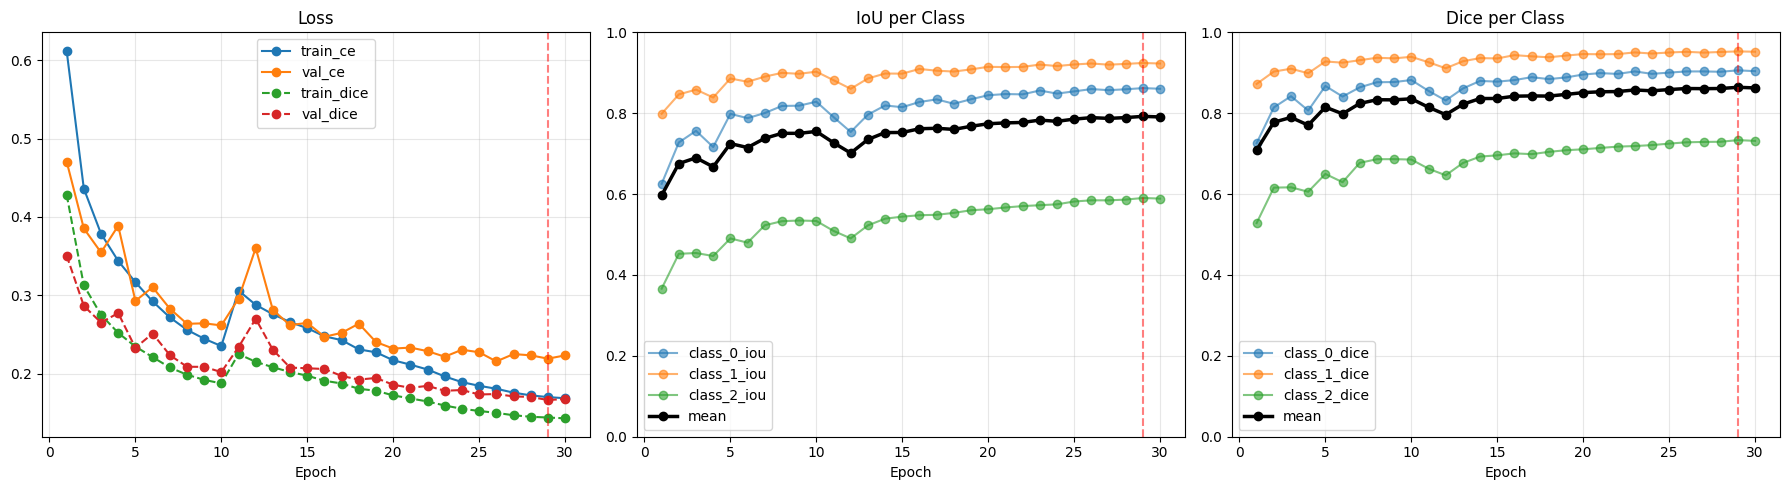

In [23]:
train_log['mean_iou'] = train_log[['class_0_iou','class_1_iou','class_2_iou']].mean(axis=1)
train_log['mean_dice'] = train_log[['class_0_dice','class_1_dice','class_2_dice']].mean(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Loss (CE + Dice, train vs val)
axes[0].plot(train_log['epoch'], train_log['train_ce_loss'], marker='o', label='train_ce')
axes[0].plot(train_log['epoch'], train_log['val_ce_loss'], marker='o', label='val_ce')
axes[0].plot(train_log['epoch'], train_log['train_dice_loss'], marker='o', linestyle='--', label='train_dice')
axes[0].plot(train_log['epoch'], train_log['val_dice_loss'], marker='o', linestyle='--', label='val_dice')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. IoU per class + mean
for c in ['class_0_iou', 'class_1_iou', 'class_2_iou']:
    axes[1].plot(train_log['epoch'], train_log[c], marker='o', alpha=0.6, label=c)
axes[1].plot(train_log['epoch'], train_log['mean_iou'], marker='o', color='black', linewidth=2.5, label='mean')
axes[1].set_title('IoU per Class')
axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3. Dice per class + mean
for c in ['class_0_dice', 'class_1_dice', 'class_2_dice']:
    axes[2].plot(train_log['epoch'], train_log[c], marker='o', alpha=0.6, label=c)
axes[2].plot(train_log['epoch'], train_log['mean_dice'], marker='o', color='black', linewidth=2.5, label='mean')
axes[2].set_title('Dice per Class')
axes[2].set_xlabel('Epoch')
axes[2].set_ylim(0, 1)
axes[2].legend()
axes[2].grid(alpha=0.3)

# mark best epoch (lowest combined val loss) on all plots
train_log['val_loss'] = train_log['val_ce_loss'] + train_log['val_dice_loss']
best_epoch = train_log.loc[train_log['val_loss'].idxmin(), 'epoch']
for ax in axes:
    ax.axvline(best_epoch, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('train_log_overview.png', dpi=150)
plt.show()

## Check performance

In [24]:
@torch.no_grad()
def predict(model, image):
   image = image.unsqueeze(0).to(device)
   preds = model(image)
   preds = torch.softmax(preds, dim=1)
   preds = torch.argmax(preds, dim=1)

   return preds.squeeze(0).detach().cpu()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.64].


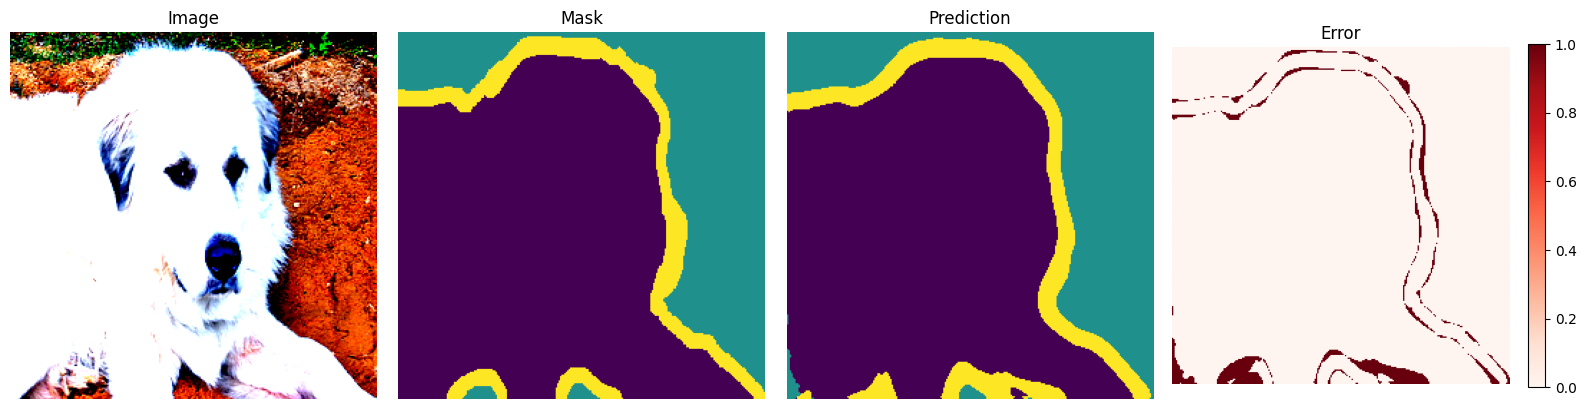

In [25]:
img, tar = val_data[-1]

pred = predict(unet, img)

visualize(img, tar, num_classes=num_classes, pred=pred, show_error=True)

In [26]:
!rm /kaggle/working/annotations.tar.gz
!rm /kaggle/working/images.tar.gz
!rm -rf annotations
!rm -rf images